# Experiment 2: Email Spam/Ham Classification using Naive Bayes and KNN

Comparing Gaussian/Multinomial/Bernoulli Naive Bayes against tuned KNN on the Spambase dataset.

Place `spambase.csv` in a `data/` folder next to this notebook before running.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import (train_test_split, GridSearchCV, RandomizedSearchCV,
                                      StratifiedKFold, cross_val_score)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, precision_recall_curve,
                              confusion_matrix)
from scipy.stats import randint

sns.set_style("whitegrid")
rng = 42

## 1-3. Load Dataset, Check Missing Values

In [2]:
df = pd.read_csv("data/spambase.csv")
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
df["spam"].value_counts()

Shape: (4601, 58)
Missing values: 0


spam
0    2788
1    1813
Name: count, dtype: int64

In [3]:
X = df.drop(columns=["spam"])
y = df["spam"]
feature_names = X.columns.tolist()
X.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191


## 4. Exploratory Data Analysis

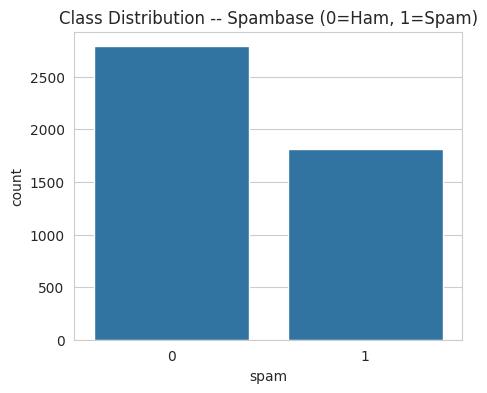

In [4]:
plt.figure(figsize=(5,4))
sns.countplot(x=y)
plt.title("Class Distribution -- Spambase (0=Ham, 1=Spam)")
plt.show()

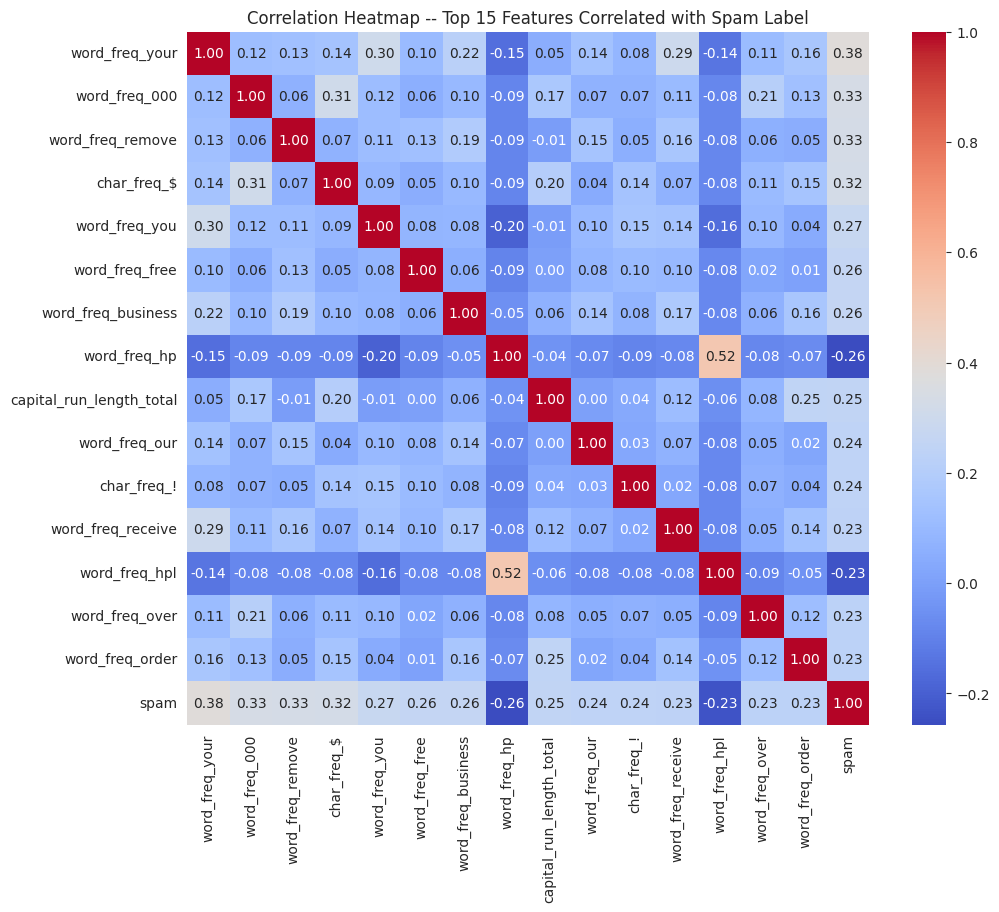

In [5]:
top_corr_feats = X.corrwith(y).abs().sort_values(ascending=False).head(15).index.tolist()
plt.figure(figsize=(11,9))
sns.heatmap(pd.concat([X[top_corr_feats], y], axis=1).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap -- Top 15 Features Correlated with Spam Label")
plt.show()

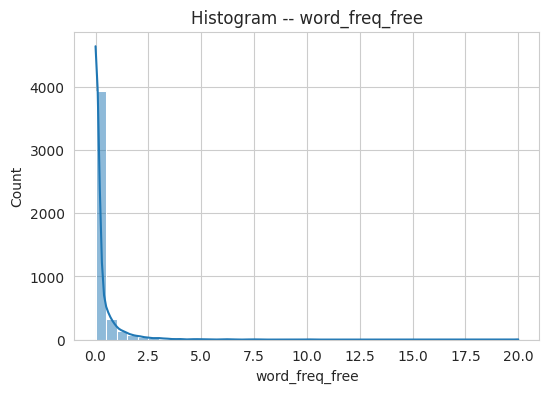

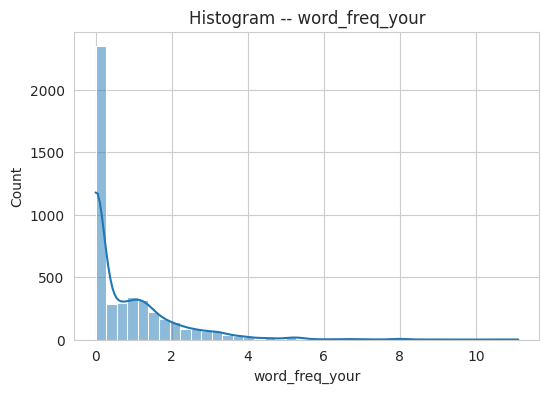

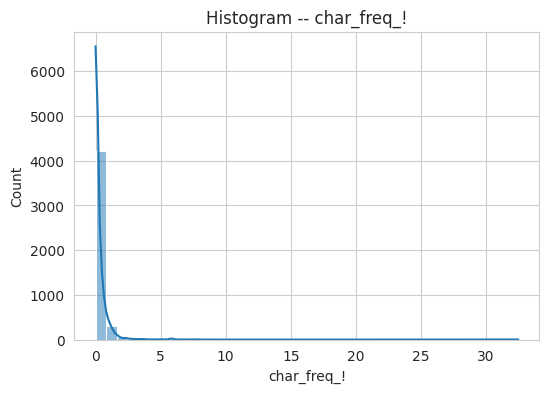

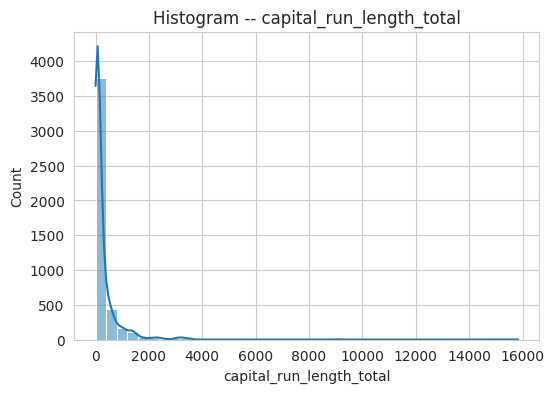

In [6]:
important_feats = ["word_freq_free", "word_freq_your", "char_freq_!", "capital_run_length_total"]
for feat in important_feats:
    plt.figure(figsize=(6,4))
    sns.histplot(X[feat], bins=40, kde=True)
    plt.title(f"Histogram -- {feat}")
    plt.show()

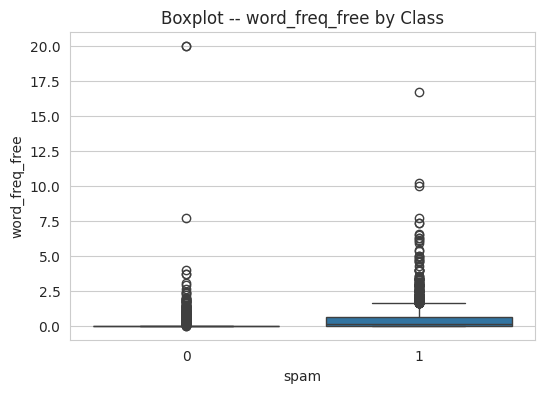

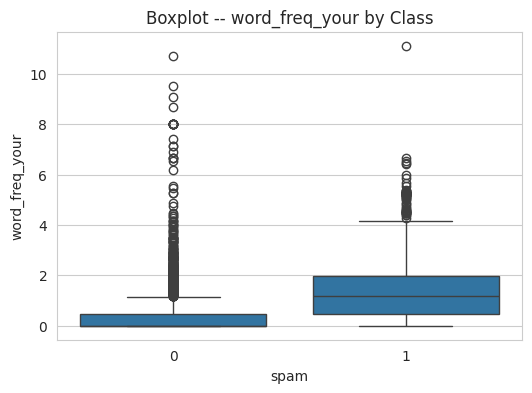

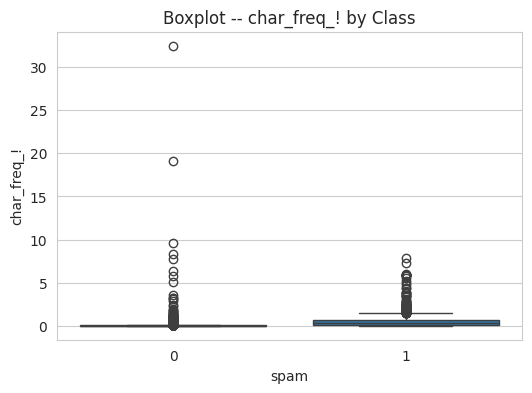

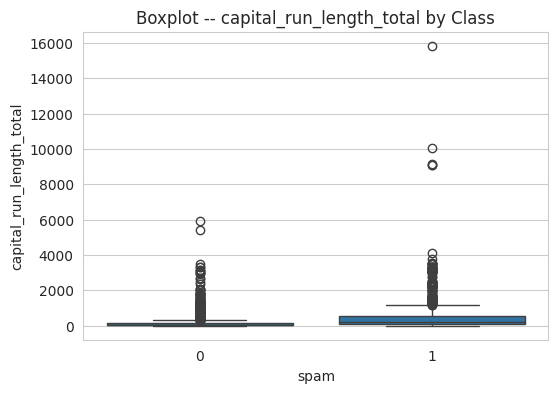

In [7]:
for feat in important_feats:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=y, y=X[feat])
    plt.title(f"Boxplot -- {feat} by Class")
    plt.show()

## 5. Train-Test Split and Feature Scaling

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=rng)
print("Train:", X_train.shape, " Test:", X_test.shape)

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

Train: (3680, 57)  Test: (921, 57)


In [9]:
def evaluate(model, Xtr, ytr, Xte, yte):
    t0 = time.time()
    model.fit(Xtr, ytr)
    train_time = time.time() - t0
    t0 = time.time()
    pred = model.predict(Xte)
    pred_time = time.time() - t0
    proba = model.predict_proba(Xte)[:, 1] if hasattr(model, "predict_proba") else None
    metrics = dict(
        Accuracy=accuracy_score(yte, pred),
        Precision=precision_score(yte, pred),
        Recall=recall_score(yte, pred),
        F1=f1_score(yte, pred),
        ROC_AUC=roc_auc_score(yte, proba) if proba is not None else None,
        TrainTime=train_time,
        PredictTime=pred_time,
    )
    return metrics, pred, proba

## 6. Train Gaussian, Multinomial, Bernoulli Naive Bayes

In [10]:
nb_results, nb_preds, nb_probas, nb_models = {}, {}, {}, {}

gnb = GaussianNB()
nb_results["Gaussian"], nb_preds["Gaussian"], nb_probas["Gaussian"] = evaluate(gnb, X_train, y_train, X_test, y_test)

mnb = MultinomialNB()
nb_results["Multinomial"], nb_preds["Multinomial"], nb_probas["Multinomial"] = evaluate(mnb, X_train, y_train, X_test, y_test)

bnb = BernoulliNB()
nb_results["Bernoulli"], nb_preds["Bernoulli"], nb_probas["Bernoulli"] = evaluate(bnb, X_train, y_train, X_test, y_test)

pd.DataFrame(nb_results).T

,Accuracy,Precision,Recall,F1,ROC_AUC,TrainTime,PredictTime
Gaussian,0.833876,0.717842,0.953168,0.818935,0.944926,0.020428,0.002578
Multinomial,0.776330,0.719888,0.707989,0.713889,0.824812,0.003383,0.001468
Bernoulli,0.876221,0.871642,0.804408,0.836676,0.949646,0.005744,0.002528


## 7. KNN -- Varying k

In [11]:
k_values = [1, 3, 5, 7, 9, 11]
knn_k_results = {}
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    m, _, _ = evaluate(knn, X_train_std, y_train, X_test_std, y_test)
    knn_k_results[k] = m

pd.DataFrame(knn_k_results).T

,Accuracy,Precision,Recall,F1,ROC_AUC,TrainTime,PredictTime
1,0.899023,0.879213,0.862259,0.870654,0.892599,0.002265,0.050148
3,0.897937,0.872576,0.867769,0.870166,0.936044,0.001208,0.022813
5,0.907709,0.886111,0.878788,0.882434,0.950564,0.001108,0.025520
7,0.908795,0.892958,0.873278,0.883008,0.956599,0.001165,0.023171
9,0.908795,0.892958,0.873278,0.883008,0.960174,0.001093,0.023348
11,0.909881,0.900000,0.867769,0.883590,0.962173,0.001253,0.024015


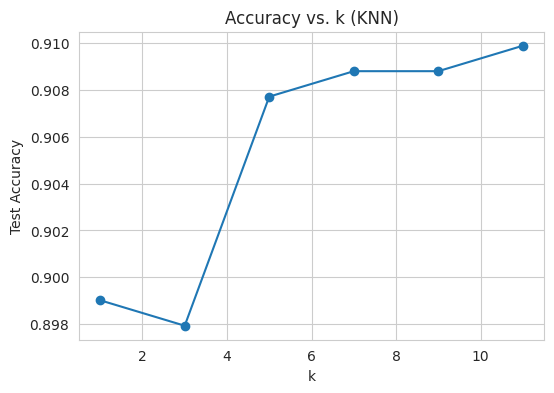

In [12]:
plt.figure(figsize=(6,4))
plt.plot(k_values, [knn_k_results[k]["Accuracy"] for k in k_values], "o-")
plt.xlabel("k")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs. k (KNN)")
plt.show()

## 8. GridSearchCV for KNN

In [13]:
param_grid = {
    "n_neighbors": [1, 3, 5, 7, 9, 11, 13, 15],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"],
}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=rng)

t0 = time.time()
grid = GridSearchCV(KNeighborsClassifier(), param_grid=param_grid, cv=skf, scoring="accuracy", n_jobs=-1)
grid.fit(X_train_std, y_train)
grid_time = time.time() - t0

print("Best params:", grid.best_params_)
print("Best CV accuracy:", round(grid.best_score_, 4))
print("Execution time (s):", round(grid_time, 3))

Best params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Best CV accuracy: 0.9253
Execution time (s): 10.814


## 9. RandomizedSearchCV for KNN

In [14]:
param_dist = {
    "n_neighbors": randint(1, 31),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"],
}
t0 = time.time()
rand_search = RandomizedSearchCV(KNeighborsClassifier(), param_distributions=param_dist,
                                  n_iter=20, cv=skf, scoring="accuracy", n_jobs=-1, random_state=rng)
rand_search.fit(X_train_std, y_train)
rand_time = time.time() - t0

print("Best params:", rand_search.best_params_)
print("Best CV accuracy:", round(rand_search.best_score_, 4))
print("Execution time (s):", round(rand_time, 3))

Best params: {'metric': 'euclidean', 'n_neighbors': 10, 'weights': 'distance'}
Best CV accuracy: 0.9234
Execution time (s): 6.373


In [15]:
best_knn_params = grid.best_params_
best_knn = KNeighborsClassifier(**best_knn_params)
knn_full_metrics, knn_pred, knn_proba = evaluate(best_knn, X_train_std, y_train, X_test_std, y_test)
knn_full_metrics

{'Accuracy': 0.9207383279044516,
 'Precision': 0.9420731707317073,
 'Recall': 0.8512396694214877,
 'F1': 0.894356005788712,
 'ROC_AUC': 0.9712126149076296,
 'TrainTime': 0.0015168190002441406,
 'PredictTime': 0.17381548881530762}

### GridSearchCV Heatmap and RandomizedSearchCV Score Distribution

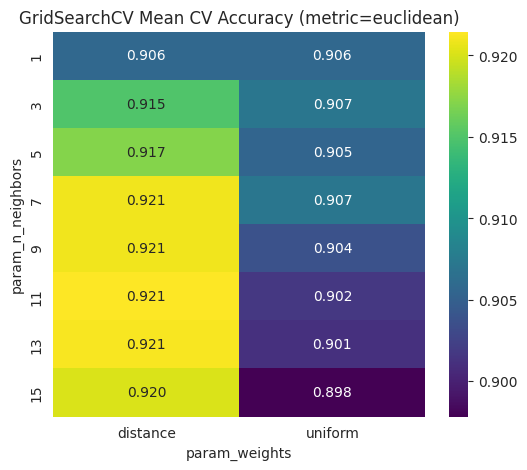

In [16]:
grid_cv_results_df = pd.DataFrame(grid.cv_results_)
sub = grid_cv_results_df[grid_cv_results_df["param_metric"] == "euclidean"]
pivot = sub.pivot(index="param_n_neighbors", columns="param_weights", values="mean_test_score")

plt.figure(figsize=(6,5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("GridSearchCV Mean CV Accuracy (metric=euclidean)")
plt.show()

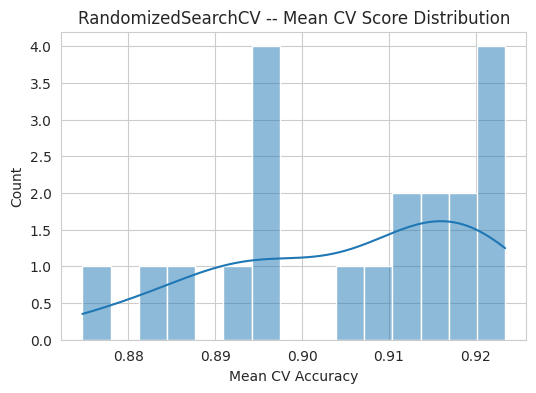

In [17]:
rand_cv_results_df = pd.DataFrame(rand_search.cv_results_)
plt.figure(figsize=(6,4))
sns.histplot(rand_cv_results_df["mean_test_score"], bins=15, kde=True)
plt.title("RandomizedSearchCV -- Mean CV Score Distribution")
plt.xlabel("Mean CV Accuracy")
plt.show()

## 10. KDTree vs. BallTree

In [18]:
tree_results = {}
for algo in ["kd_tree", "ball_tree"]:
    knn_algo = KNeighborsClassifier(n_neighbors=best_knn_params["n_neighbors"],
                                     weights=best_knn_params["weights"],
                                     metric=best_knn_params["metric"],
                                     algorithm=algo)
    m, _, _ = evaluate(knn_algo, X_train_std, y_train, X_test_std, y_test)
    tree_results[algo] = m

pd.DataFrame(tree_results).T

,Accuracy,Precision,Recall,F1,ROC_AUC,TrainTime,PredictTime
kd_tree,0.920738,0.942073,0.85124,0.894356,0.971213,0.023500,0.236026
ball_tree,0.920738,0.942073,0.85124,0.894356,0.971213,0.010217,0.211708


## 11. 5-Fold Cross-Validation: Best NB vs. Best KNN

In [19]:
best_nb_name = max(nb_results, key=lambda k: nb_results[k]["Accuracy"])
print("Best NB variant:", best_nb_name)

best_nb_model = {"Gaussian": GaussianNB(), "Multinomial": MultinomialNB(), "Bernoulli": BernoulliNB()}[best_nb_name]
nb_cv_scores = cross_val_score(best_nb_model, X, y, cv=skf, scoring="accuracy")

X_std_full = scaler.fit_transform(X)
knn_cv_scores = cross_val_score(KNeighborsClassifier(**best_knn_params), X_std_full, y, cv=skf, scoring="accuracy")

print("NB fold scores:", nb_cv_scores.round(4))
print("KNN fold scores:", knn_cv_scores.round(4))
print("NB avg:", round(nb_cv_scores.mean(),4), " KNN avg:", round(knn_cv_scores.mean(),4))

Best NB variant: Bernoulli


NB fold scores: [0.8849 0.8859 0.8793 0.9022 0.8815]
KNN fold scores: [0.9164 0.9326 0.9359 0.9217 0.9217]
NB avg: 0.8868  KNN avg: 0.9257


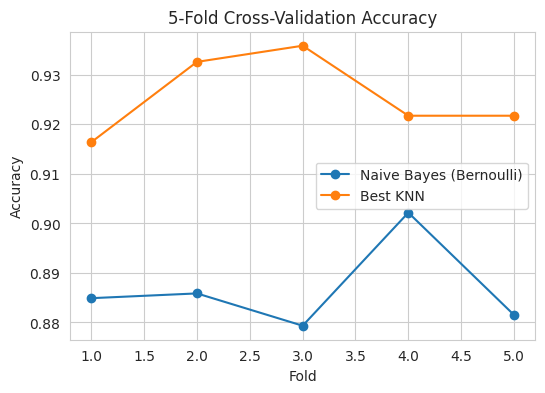

In [20]:
plt.figure(figsize=(6,4))
folds = list(range(1,6))
plt.plot(folds, nb_cv_scores, "o-", label=f"Naive Bayes ({best_nb_name})")
plt.plot(folds, knn_cv_scores, "o-", label="Best KNN")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross-Validation Accuracy")
plt.legend()
plt.show()

## 12. Training / Prediction Time Comparison

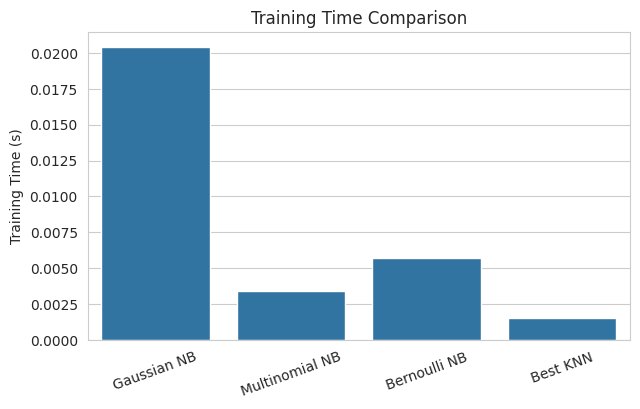

In [21]:
time_table = {
    "Gaussian NB": (nb_results["Gaussian"]["TrainTime"], nb_results["Gaussian"]["PredictTime"]),
    "Multinomial NB": (nb_results["Multinomial"]["TrainTime"], nb_results["Multinomial"]["PredictTime"]),
    "Bernoulli NB": (nb_results["Bernoulli"]["TrainTime"], nb_results["Bernoulli"]["PredictTime"]),
    "Best KNN": (knn_full_metrics["TrainTime"], knn_full_metrics["PredictTime"]),
}
names = list(time_table.keys())
train_times = [time_table[n][0] for n in names]
pred_times = [time_table[n][1] for n in names]

plt.figure(figsize=(7,4))
sns.barplot(x=names, y=train_times)
plt.ylabel("Training Time (s)")
plt.title("Training Time Comparison")
plt.xticks(rotation=20)
plt.show()

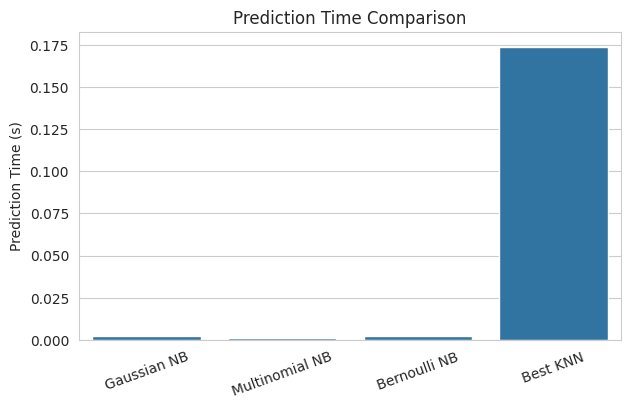

In [22]:
plt.figure(figsize=(7,4))
sns.barplot(x=names, y=pred_times)
plt.ylabel("Prediction Time (s)")
plt.title("Prediction Time Comparison")
plt.xticks(rotation=20)
plt.show()

## 13. Confusion Matrices, ROC Curves, Precision-Recall Curves

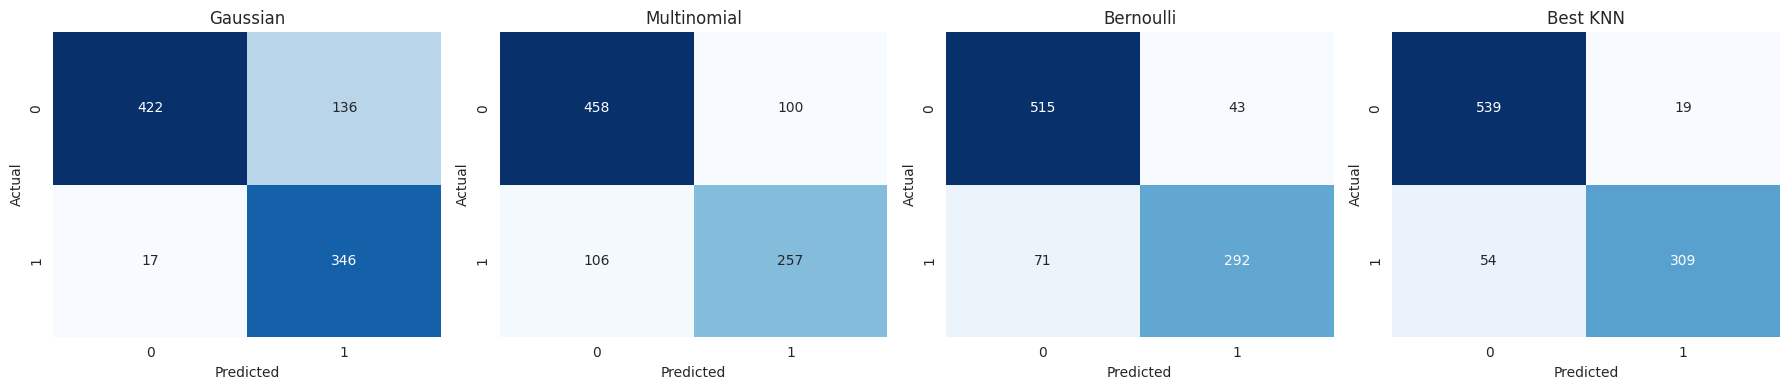

In [23]:
all_models_preds = dict(nb_preds)
all_models_preds["Best KNN"] = knn_pred
all_models_probas = dict(nb_probas)
all_models_probas["Best KNN"] = knn_proba

fig, axes = plt.subplots(1, 4, figsize=(18,4))
for ax, name in zip(axes, ["Gaussian", "Multinomial", "Bernoulli", "Best KNN"]):
    cm = confusion_matrix(y_test, all_models_preds[name])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

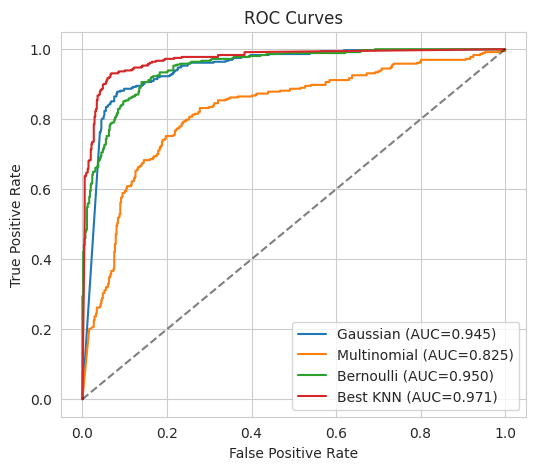

In [24]:
plt.figure(figsize=(6,5))
for name in ["Gaussian", "Multinomial", "Bernoulli", "Best KNN"]:
    fpr, tpr, _ = roc_curve(y_test, all_models_probas[name])
    auc = roc_auc_score(y_test, all_models_probas[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],"k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

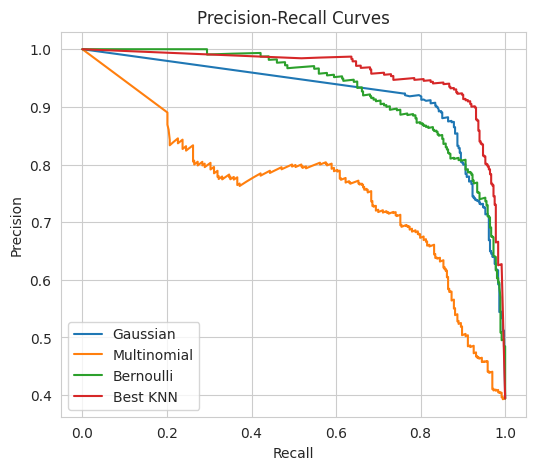

In [25]:
plt.figure(figsize=(6,5))
for name in ["Gaussian", "Multinomial", "Bernoulli", "Best KNN"]:
    prec, rec, _ = precision_recall_curve(y_test, all_models_probas[name])
    plt.plot(rec, prec, label=name)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()

## 14. Classifier Comparison Bar Chart

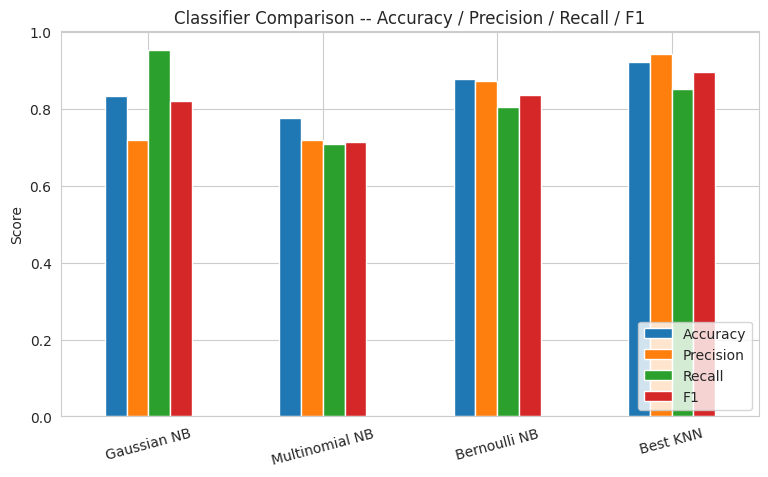

,Accuracy,Precision,Recall,F1
Gaussian NB,0.833876,0.717842,0.953168,0.818935
Multinomial NB,0.776330,0.719888,0.707989,0.713889
Bernoulli NB,0.876221,0.871642,0.804408,0.836676
Best KNN,0.920738,0.942073,0.851240,0.894356


In [26]:
compare_df = pd.DataFrame({
    "Gaussian NB": nb_results["Gaussian"],
    "Multinomial NB": nb_results["Multinomial"],
    "Bernoulli NB": nb_results["Bernoulli"],
    "Best KNN": knn_full_metrics,
}).T[["Accuracy", "Precision", "Recall", "F1"]]

compare_df.plot(kind="bar", figsize=(9,5))
plt.title("Classifier Comparison -- Accuracy / Precision / Recall / F1")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.show()
compare_df

## Additional Tasks

In [27]:
# (a) Different train-test splits
split_results = {}
for test_size in [0.4, 0.3, 0.2, 0.1]:
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=test_size, stratify=y, random_state=rng)
    sc = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr)
    Xte_s = sc.transform(Xte)
    knn_tmp = KNeighborsClassifier(**best_knn_params)
    knn_tmp.fit(Xtr_s, ytr)
    acc = accuracy_score(yte, knn_tmp.predict(Xte_s))
    split_results[f"{int((1-test_size)*100)}:{int(test_size*100)}"] = round(acc, 4)
split_results

{'60:40': 0.9202, '70:30': 0.9312, '80:20': 0.9207, '90:10': 0.9067}

In [28]:
# (b) Euclidean vs Manhattan at fixed k
dist_results = {}
for metric in ["euclidean", "manhattan"]:
    knn_tmp = KNeighborsClassifier(n_neighbors=best_knn_params["n_neighbors"], metric=metric)
    m, _, _ = evaluate(knn_tmp, X_train_std, y_train, X_test_std, y_test)
    dist_results[metric] = m["Accuracy"]
dist_results

{'euclidean': 0.9087947882736156, 'manhattan': 0.9033659066232356}

In [29]:
# (c) Weighted vs uniform KNN
weight_results = {}
for w in ["uniform", "distance"]:
    knn_tmp = KNeighborsClassifier(n_neighbors=best_knn_params["n_neighbors"], weights=w)
    m, _, _ = evaluate(knn_tmp, X_train_std, y_train, X_test_std, y_test)
    weight_results[w] = m["Accuracy"]
weight_results

{'uniform': 0.9087947882736156, 'distance': 0.9163952225841476}

## Summary

See the accompanying report (`Experiment2.pdf`) for the full discussion of the analysis questions, complexity analysis, and overfitting/underfitting behaviour grounded in these results.